In [7]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt

In [8]:
EDGE_TYPES = {
    0:  'Horizontal',
    1:  'Vertical',
    2:  'Diagonal BL-TR',
    3:  'Diagonal TL-BR',
    4:  'Corner Top-Left',
    5:  'Corner Top-Right',
    6:  'Corner Bottom-Left',
    7:  'Corner Bottom-Right',
    8:  'T-Junction Top',
    9:  'T-Junction Bottom',
    10: 'Cross / Intersection',
    11: 'No Edge'
}
NUM_CLASSES = len(EDGE_TYPES)
PATCH_SIZE = 5
for k, v in EDGE_TYPES .items():
    print(f'[{k:2d}]{v}')

[ 0]Horizontal
[ 1]Vertical
[ 2]Diagonal BL-TR
[ 3]Diagonal TL-BR
[ 4]Corner Top-Left
[ 5]Corner Top-Right
[ 6]Corner Bottom-Left
[ 7]Corner Bottom-Right
[ 8]T-Junction Top
[ 9]T-Junction Bottom
[10]Cross / Intersection
[11]No Edge


In [17]:
def make_base_pattern(edge_type , size = 5 ):
    p = np.zeros((size,size),dtype=np.float32)
    m= size//2

    if edge_type == 0:
        p[m,:] =1.0
    elif edge_type == 1:
        p[:,m]=1.0
    elif edge_type == 2:
        for i in range(size):
            p[size - 1 - i,i]=1.0
    elif edge_type == 3:
        np.fill_diagonal(p,1.0)
    elif edge_type == 4:
        p[m,m:] = 1.0
        p[m:,m] = 1.0
    elif edge_type == 5 :
        p[m,:m+1] = 1.0
        p[m:,m] = 1.0
    elif edge_type == 6 :
        p[m,m:] = 1.0
        p[:m+1 , m] = 1.0
    elif edge_type == 7:
        p[m,:m+1]= 1.0
        p[:m+1,m] = 1.0
    elif edge_type == 8:
        p[m, : ] = 1.0
        p[:m+1,m] = 1.0
    elif edge_type == 9 :
        p[m,:] = 1.0
        p[m:,m] = 1.0
    elif edge_type == 10:
        p[m,:] = 1.0
        p[:,m] = 1.0
    elif edge_type == 11:
        pass
    return p 
print(" Base pattern function defined ")
        

 Base pattern function defined 


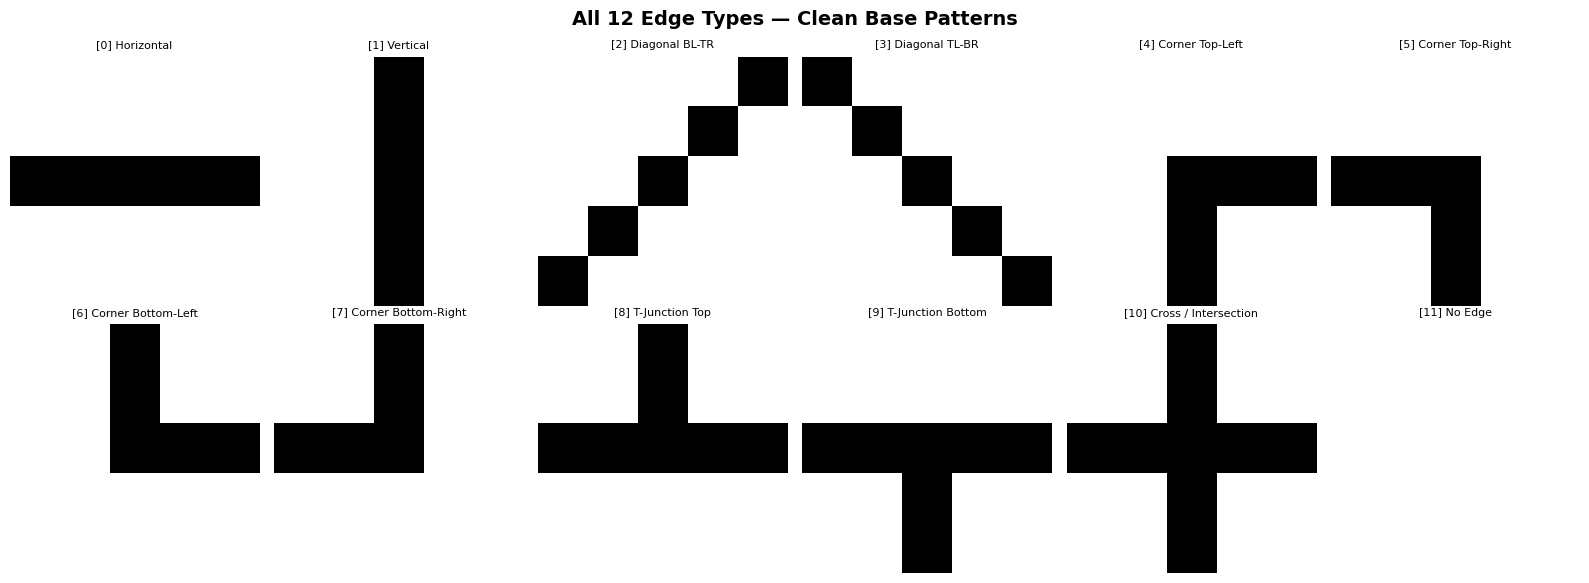

Saved edge type chart.


In [18]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
os.makedirs("images", exist_ok=True)
fig.suptitle('All 12 Edge Types — Clean Base Patterns', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    pat = make_base_pattern(idx)
    ax.imshow(pat, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'[{idx}] {EDGE_TYPES[idx]}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('images/edge_type_reference.jpeg', dpi=120, bbox_inches='tight')
plt.show()
print('Saved edge type chart.')

In [26]:
def add_gausian_node(patch,sigma = 0.1):
    noisy = patch + np.random.normal(0,sigma,patch.shape)
    return np.clip(noisy,0,1).astype(np.float32)

def add_salt_pepper(patch,prob = 0.05):
    noisy = patch.copy()
    mask = np.random.rand(*patch.shape)
    noisy[mask < prob /2] =0.0
    noisy [ mask > 1- prob / 2 ] = 1.0 
    return noisy 

def add_brightness(patch , shift_range = 0.15):
    shift = np.random.uniform(-shift_range, shift_range)
    return np.clip(patch + shift,0,1).astype(np.float32)

def generate_sample(edge_type , size = 5):
    patch = make_base_pattern(edge_type,size).copy()
    noise_level = np.random.choice([0.05,0.10,0.15,0.20])
    patch = add_gausian_node(patch,sigma=noise_level)
    if np.random.rand()>0.5:
        patch= add_salt_pepper(patch,prob =0.04)
    patch = add_brightness(patch)
    return patch 

print("Augmentation function defined .")


Augmentation function defined .


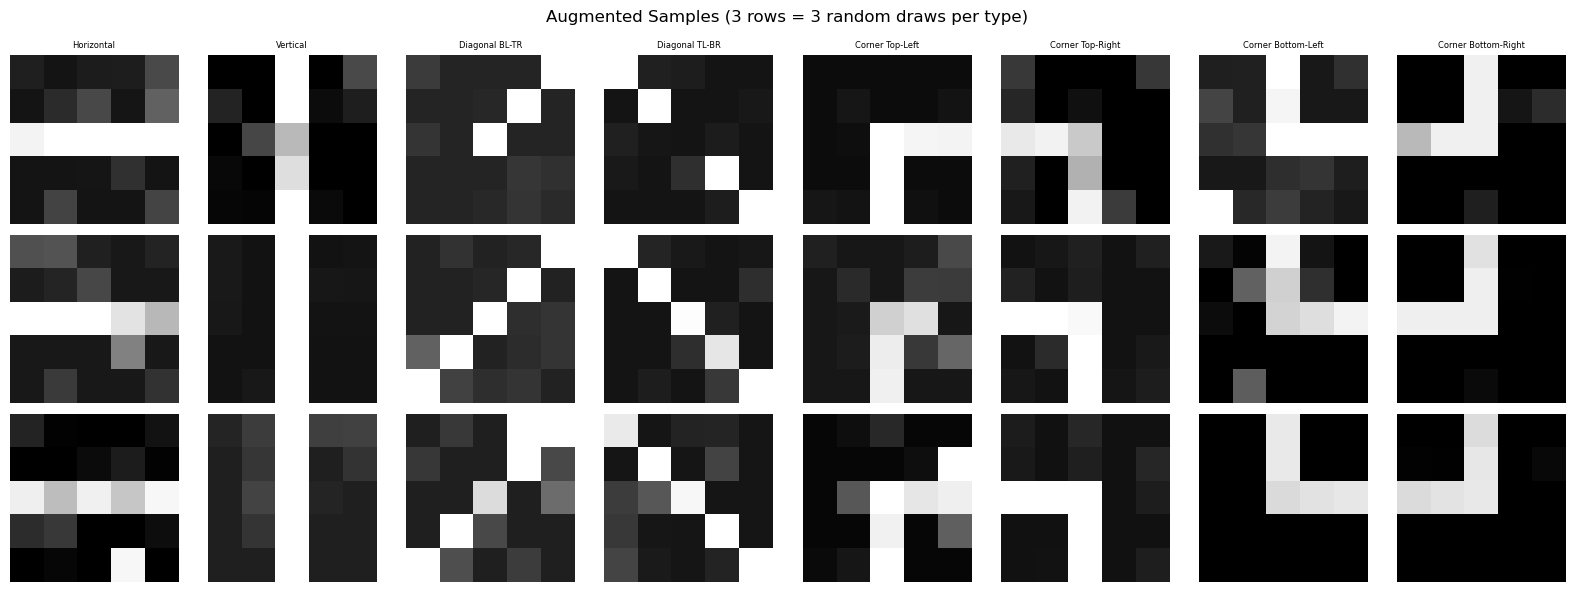

In [27]:

# Preview noisy samples for a few edge types
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Augmented Samples (3 rows = 3 random draws per type)', fontsize=12)

for row in range(3):
    for col in range(8):
        sample = generate_sample(col)
        axes[row, col].imshow(sample, cmap='gray', vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(EDGE_TYPES[col], fontsize=6)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [30]:
SAMPLES_PER_CLASS = 1000
SIZE = 5 
x_list , y_list = [],[]
for edge_type in range (NUM_CLASSES):
    for _ in range(SAMPLES_PER_CLASS):
        sample = generate_sample(edge_type , SIZE)
        x_list.append(sample)
        y_list.append(edge_type)
    print(f"Generate {SAMPLES_PER_CLASS} samples for [{edge_type}] {EDGE_TYPES[edge_type]}")

x  = np.array(x_list).reshape(-1,SIZE,SIZE , 1)
y = np.array(y_list)

idx = np.random.permutation(len(x))
x,y = x[idx],y[idx]

print(f'\nDataset shape: X={x.shape}, y={y.shape}')
print(f'Total samples: {len(x)}')


Generate 1000 samples for [0] Horizontal
Generate 1000 samples for [1] Vertical
Generate 1000 samples for [2] Diagonal BL-TR
Generate 1000 samples for [3] Diagonal TL-BR
Generate 1000 samples for [4] Corner Top-Left
Generate 1000 samples for [5] Corner Top-Right
Generate 1000 samples for [6] Corner Bottom-Left
Generate 1000 samples for [7] Corner Bottom-Right
Generate 1000 samples for [8] T-Junction Top
Generate 1000 samples for [9] T-Junction Bottom
Generate 1000 samples for [10] Cross / Intersection
Generate 1000 samples for [11] No Edge

Dataset shape: X=(12000, 5, 5, 1), y=(12000,)
Total samples: 12000


C:\Users\pranj\AppData\Local\Temp\ipykernel_31884\3858317039.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EDGE_TYPES[i] for i in unique], rotation=35, ha='right', fontsize=8)


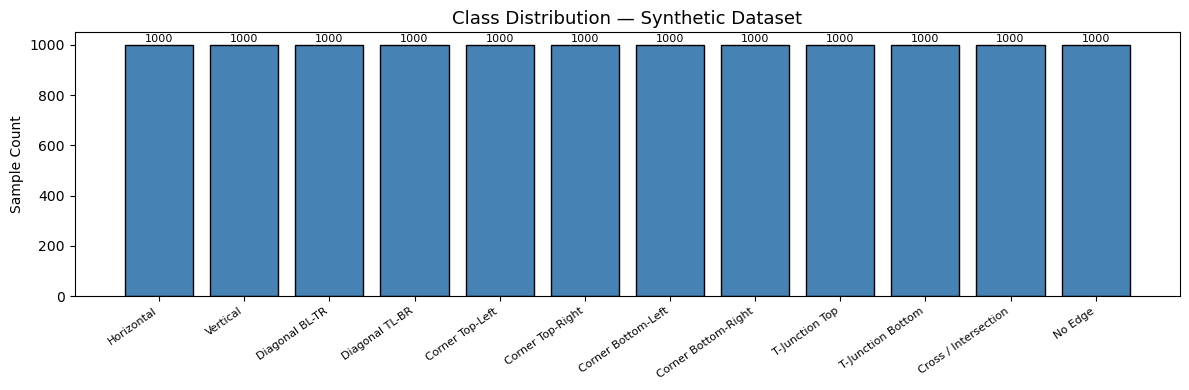

Balanced dataset confirmed.


In [31]:
unique, counts = np.unique(y, return_counts=True)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar([EDGE_TYPES[i] for i in unique], counts, color='steelblue', edgecolor='black')
ax.set_title('Class Distribution — Synthetic Dataset', fontsize=13)
ax.set_ylabel('Sample Count')
ax.set_xticklabels([EDGE_TYPES[i] for i in unique], rotation=35, ha='right', fontsize=8)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print('Balanced dataset confirmed.' if len(set(counts)) == 1 else 'Note: class imbalance detected.')

In [33]:
np.save('X_synthetic.npy', x)
np.save('y_synthetic.npy', y)

print(f'Saved X_synthetic.npy  — shape: {x.shape}')
print(f'Saved y_synthetic.npy  — shape: {y.shape}')
print('\n→ Next: Run Notebook 2 (Training_CNN.ipynb)')

Saved X_synthetic.npy  — shape: (12000, 5, 5, 1)
Saved y_synthetic.npy  — shape: (12000,)

→ Next: Run Notebook 2 (Training_CNN.ipynb)
